# Rb Gaussian Beam Omega-Stark Dictionary

This notebook computes the correlated `omega_rb` and `rb_stark_shift` dictionary used by `single_plaquet.ipynb`.

The model assumes the atom is in the waist plane of the two Rydberg excitation beams. A transverse displacement changes the local probe and coupling intensities, which changes both the two-photon Rabi frequency and the differential AC Stark shift returned by ARC's `twoPhotonRydbergExcitation`.

The output JSON has the form

```json
{
  "0.0": {"omega_rb": 1.0, "rb_stark_shift": 0.0},
  "0.1": {"omega_rb": 0.99, "rb_stark_shift": -0.002}
}
```

The key is the displacement in units of the Gaussian intensity sigma. The values are dimensionless GRAPE units normalized by the center Rabi frequency \(\Omega_{\max}\):

$$
\omega_{\rm rb}(x)=\frac{|\Omega_R(x)|}{|\Omega_R(0)|},
\qquad
\Delta_{\rm rb}(x)=\frac{[\Delta_g(x)+\Delta_r(x)]-[\Delta_g(0)+\Delta_r(0)]}{|\Omega_R(0)|}.
$$

In [1]:
from __future__ import annotations

from dataclasses import asdict, dataclass
import json
import os
from pathlib import Path
import shutil
from typing import Protocol

notebook_cwd = Path.cwd()
if notebook_cwd.name == "stabilizer_readout":
    notebook_dir = notebook_cwd
    project_root = notebook_cwd.parent.parent
elif notebook_cwd.name == "examples":
    notebook_dir = notebook_cwd / "stabilizer_readout"
    project_root = notebook_cwd.parent
else:
    project_root = notebook_cwd
    notebook_dir = project_root / "examples" / "stabilizer_readout"

os.environ["MPLCONFIGDIR"] = str(notebook_dir / ".matplotlib-cache")
os.environ["XDG_CACHE_HOME"] = str(notebook_dir / ".cache")

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import brentq

## ARC Adapter

ARC stores alkali data in a writable cache directory. The helper below copies ARC's package data into `examples/stabilizer_readout/.arc-data` and constructs a local `Rubidium87` subclass that reads and writes there.

The wrapped ARC call is

$$
\texttt{twoPhotonRydbergExcitation}(P_p,w_p,q_p,P_c,w_c,q_c,\Delta,f_g,m_{f_g},n_e,l_e,j_e,n_r,l_r,j_r,m_{j_r}),
$$

and returns \(\Omega_R,\Delta_g,\Delta_r,P_{\rm sc}\) in SI angular-frequency units.

In [2]:
@dataclass(frozen=True)
class TwoPhotonSettings:
    probe_power_w: float
    probe_waist_m: float
    probe_polarization: int
    coupling_power_w: float
    coupling_waist_m: float
    coupling_polarization: int
    ground_f: int
    ground_mf: int
    intermediate_n: int
    intermediate_l: int
    intermediate_j: float
    rydberg_n: int
    rydberg_l: int
    rydberg_j: float
    rydberg_mj: float


@dataclass(frozen=True)
class TwoPhotonResult:
    omega_r_rad_s: float
    delta_g_rad_s: float
    delta_r_rad_s: float
    scatter_probability: float


class TwoPhotonAtom(Protocol):
    def twoPhotonRydbergExcitation(
        self,
        Pp: float,
        wp: float,
        qp: int,
        Pc: float,
        wc: float,
        qc: int,
        Delta: float,
        fg: int,
        mfg: int,
        ne: int,
        le: int,
        je: float,
        nr: int,
        lr: int,
        jr: float,
        mjr: float,
    ) -> tuple[object, object, object, object]:
        ...


def scalar_arc_value(value: object, name: str) -> float:
    array = np.asarray(value)
    if array.shape != ():
        raise ValueError(f"ARC returned non-scalar {name}: shape={array.shape}")
    return float(array)


def copy_arc_data(source_dir: Path, target_dir: Path) -> None:
    if not source_dir.exists():
        raise FileNotFoundError(f"ARC data directory does not exist: {source_dir}")
    target_dir.mkdir(parents=True, exist_ok=True)
    for source_item in source_dir.iterdir():
        target_item = target_dir / source_item.name
        if source_item.is_file():
            shutil.copy2(source_item, target_item)
        elif source_item.is_dir():
            shutil.copytree(source_item, target_item, dirs_exist_ok=True)
        else:
            raise ValueError(f"Unsupported ARC data item: {source_item}")


def make_rubidium87(arc_data_dir: Path) -> TwoPhotonAtom:
    try:
        import arc
        from arc import Rubidium87
    except ModuleNotFoundError as error:
        raise ModuleNotFoundError(
            "ARC is required for this notebook. Install it with "
            "`python -m pip install -e '.[atom-physics]'`."
        ) from error

    source_dir = Path(arc.__file__).resolve().parent / "data"
    copy_arc_data(source_dir=source_dir, target_dir=arc_data_dir)

    class LocalRubidium87(Rubidium87):
        dataFolder = str(arc_data_dir.resolve())

    return LocalRubidium87()


def run_two_photon(
    atom: TwoPhotonAtom,
    settings: TwoPhotonSettings,
    detuning_rad_s: float,
    probe_power_scale: float,
    coupling_power_scale: float,
) -> TwoPhotonResult:
    omega_r, delta_g, delta_r, scatter_probability = atom.twoPhotonRydbergExcitation(
        settings.probe_power_w * probe_power_scale,
        settings.probe_waist_m,
        settings.probe_polarization,
        settings.coupling_power_w * coupling_power_scale,
        settings.coupling_waist_m,
        settings.coupling_polarization,
        detuning_rad_s,
        settings.ground_f,
        settings.ground_mf,
        settings.intermediate_n,
        settings.intermediate_l,
        settings.intermediate_j,
        settings.rydberg_n,
        settings.rydberg_l,
        settings.rydberg_j,
        settings.rydberg_mj,
    )
    return TwoPhotonResult(
        omega_r_rad_s=scalar_arc_value(omega_r, "Omega_R"),
        delta_g_rad_s=scalar_arc_value(delta_g, "Delta_g"),
        delta_r_rad_s=scalar_arc_value(delta_r, "Delta_r"),
        scatter_probability=scalar_arc_value(scatter_probability, "P_sc"),
    )


def total_stark_shift(result: TwoPhotonResult) -> float:
    return result.delta_g_rad_s + result.delta_r_rad_s

## Experimental Parameters

Replace these transition and beam parameters with the experiment values. The example values are only a nonzero ARC-compatible Rb-87 configuration.

The Gaussian convention used below is

$$
I(x)/I_0=\exp\left[-\frac{1}{2}(x/\sigma)^2\right].
$$

If your `sigma` instead denotes a beam waist parameter such that \(I/I_0=\exp[-2r^2/w^2]\), edit `gaussian_intensity_scale` before generating the JSON.

In [3]:
settings = TwoPhotonSettings(
    probe_power_w=0.35,
    probe_waist_m=135e-6,
    probe_polarization=1,
    coupling_power_w=45,
    coupling_waist_m=142.3e-6,
    coupling_polarization=-1,
    ground_f=2,
    ground_mf=0,
    intermediate_n=6,
    intermediate_l=1,
    intermediate_j=1.5,
    rydberg_n=46,
    rydberg_l=0,
    rydberg_j=0.5,
    rydberg_mj=0.5,
)
# settings = TwoPhotonSettings(
#     probe_power_w=0.018,
#     probe_waist_m=60.8e-6,
#     probe_polarization=-1,
#     coupling_power_w=8.5,
#     coupling_waist_m=42.7e-6,
#     coupling_polarization=1,
#     ground_f=2,
#     ground_mf=-2,
#     intermediate_n=6,
#     intermediate_l=1,
#     intermediate_j=1.5,
#     rydberg_n=67,
#     rydberg_l=0,
#     rydberg_j=0.5,
#     rydberg_mj=-0.5,
# )

arc_data_dir = notebook_dir / ".arc-data"
output_path = notebook_dir / "omega_stark_values.json"

sigma_positions = np.linspace(0, 0.2, 61)
detuning_hz = -3.7e9
detuning_rad_s = 2.0 * np.pi * detuning_hz

atom = make_rubidium87(arc_data_dir=arc_data_dir)

## Reference Stark Shift

The single-photon detuning is fixed to

$$
\Delta/2\pi = 2.3\;\mathrm{GHz}.
$$

We do not tune the ARC Stark shift to zero directly. Instead, the center value is treated as the experimental reference and subtracted from every displaced position:

$$
\Delta_{\rm rb}(r)=\frac{\Delta_{\rm AC}(r)-\Delta_{\rm AC}(0)}{|\Omega_R(0)|},
\qquad
\Delta_{\rm AC}=\Delta_g+\Delta_r.
$$

In [4]:
reference_result = run_two_photon(
    atom=atom,
    settings=settings,
    detuning_rad_s=detuning_rad_s,
    probe_power_scale=1.0,
    coupling_power_scale=1.0,
)
reference_stark_shift_rad_s = total_stark_shift(result=reference_result)
omega_max_rad_s = abs(reference_result.omega_r_rad_s)
if omega_max_rad_s == 0.0:
    raise ValueError("Center two-photon Rabi frequency is zero; check transition and polarization settings.")

print(f"single-photon detuning: {detuning_hz / 1.0e9:.6f} GHz")
print(f"Omega_max / 2pi: {omega_max_rad_s / (2.0 * np.pi * 1.0e6):.6f} MHz")
print(f"reference Stark shift / 2pi: {reference_stark_shift_rad_s / (2.0 * np.pi * 1.0e6):.6f} MHz")

single-photon detuning: -3.700000 GHz
Omega_max / 2pi: 7.412601 MHz
reference Stark shift / 2pi: -19.719619 MHz


In [5]:
Omega_1 = atom.getRabiFrequency(n1=6, l1=0, j1=0.5, mj1=-0.5,
                n2=7, l2=1, j2=1.5, q=-1,
                laserPower=0.054*0.185, laserWaist=65.9e-6)

## Position Scan and JSON Output

With the single-photon detuning fixed, scan small transverse displacements and save the dictionary used by the GRAPE robustness block. The Stark value at the beam center is subtracted before normalization.

In [38]:
def gaussian_intensity_scale(position_sigma: float) -> float:
    if position_sigma < 0.0:
        raise ValueError(f"position_sigma must be non-negative: position_sigma={position_sigma}")
    return float(np.exp(-0.5 * position_sigma**2))


def make_omega_stark_values(
    atom: TwoPhotonAtom,
    settings: TwoPhotonSettings,
    detuning_rad_s: float,
    reference_stark_shift_rad_s: float,
    omega_max_rad_s: float,
    positions_sigma: np.ndarray,
) -> dict[float, dict[str, float]]:
    if omega_max_rad_s == 0.0:
        raise ValueError("omega_max_rad_s must be nonzero.")

    values: dict[float, dict[str, float]] = {}
    for position_sigma in positions_sigma:
        position_key = float(position_sigma)
        intensity_scale = gaussian_intensity_scale(position_sigma=position_key)
        result = run_two_photon(
            atom=atom,
            settings=settings,
            detuning_rad_s=detuning_rad_s,
            probe_power_scale=intensity_scale,
            coupling_power_scale=intensity_scale,
        )
        values[position_key] = {
            "omega_rb": abs(result.omega_r_rad_s) / omega_max_rad_s,
            "rb_stark_shift": (total_stark_shift(result) - reference_stark_shift_rad_s) / omega_max_rad_s,
        }
    return values


def save_omega_stark_values(values: dict[float, dict[str, float]], output_path: Path) -> None:
    serializable_values = {f"{key:.12g}": value for key, value in sorted(values.items())}
    output_path.write_text(json.dumps(serializable_values, indent=2, sort_keys=True), encoding="utf-8")


omega_stark_values = make_omega_stark_values(
    atom=atom,
    settings=settings,
    detuning_rad_s=detuning_rad_s,
    reference_stark_shift_rad_s=reference_stark_shift_rad_s,
    omega_max_rad_s=omega_max_rad_s,
    positions_sigma=sigma_positions,
)
save_omega_stark_values(values=omega_stark_values, output_path=output_path)

print(json.dumps({f"{key:.12g}": value for key, value in sorted(omega_stark_values.items())}, indent=2))
print(f"saved: {output_path}")

{
  "0": {
    "omega_rb": 1.0,
    "rb_stark_shift": 0.0
  },
  "0.00333333333333": {
    "omega_rb": 0.9999944444598762,
    "rb_stark_shift": -1.5194423016163243e-05
  },
  "0.00666666666667": {
    "omega_rb": 0.9999777780246895,
    "rb_stark_shift": -6.077718558204178e-05
  },
  "0.01": {
    "omega_rb": 0.9999500012499788,
    "rb_stark_shift": -0.00013674676829729493
  },
  "0.0133333333333": {
    "omega_rb": 0.9999111150616111,
    "rb_stark_shift": -0.00024310063891192583
  },
  "0.0166666666667": {
    "omega_rb": 0.999861120755726,
    "rb_stark_shift": -0.0003798352524798418
  },
  "0.02": {
    "omega_rb": 0.9998000199986666,
    "rb_stark_shift": -0.0005469460515467153
  },
  "0.0233333333333": {
    "omega_rb": 0.999727814826885,
    "rb_stark_shift": -0.0007444274664075014
  },
  "0.0266666666667": {
    "omega_rb": 0.99964450764683,
    "rb_stark_shift": -0.0009722729154172522
  },
  "0.03": {
    "omega_rb": 0.9995501012348141,
    "rb_stark_shift": -0.0012304748053

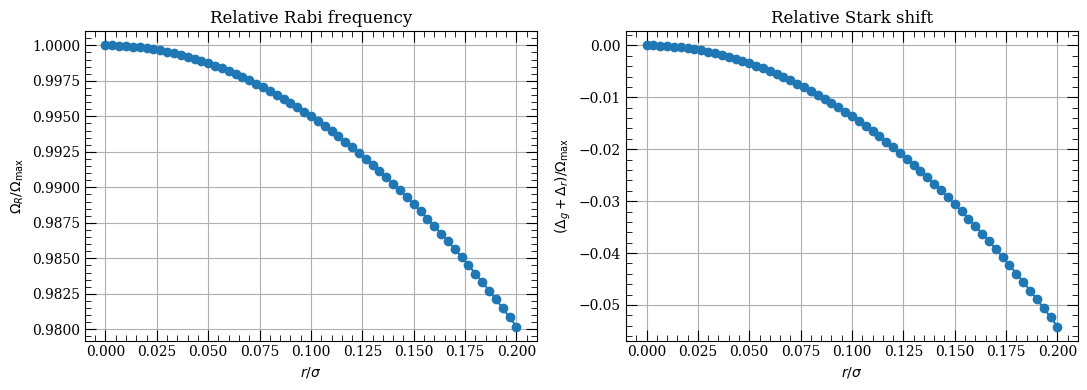

In [39]:
position_keys = np.array(sorted(omega_stark_values), dtype=np.float64)
relative_omegas = np.array([omega_stark_values[float(key)]["omega_rb"] for key in position_keys], dtype=np.float64)
relative_shifts = np.array([omega_stark_values[float(key)]["rb_stark_shift"] for key in position_keys], dtype=np.float64)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(position_keys, relative_omegas, marker="o")
axes[0].set_xlabel(r"$r/\sigma$")
axes[0].set_ylabel(r"$\Omega_R/\Omega_{\max}$")
axes[0].set_title("Relative Rabi frequency")
axes[0].grid(True)

axes[1].plot(position_keys, relative_shifts, marker="o")
axes[1].set_xlabel(r"$r/\sigma$")
axes[1].set_ylabel(r"$(\Delta_g+\Delta_r)/\Omega_{\max}$")
axes[1].set_title("Relative Stark shift")
axes[1].grid(True)

fig.tight_layout()
plt.show()

## Use in `single_plaquet.ipynb`

After this notebook saves `omega_stark_values.json`, rerun the Omega-Stark sensitivity block in `single_plaquet.ipynb`. That block reads the JSON, rebuilds the Hamiltonian at each displacement, and plots \(\log_{10}(1-F)\) versus \(r/\sigma\).